Dla ustalonej długości danych 𝑁 = 100 i dla 𝜃0 = 1 i 𝜃1 ∈
{−0,9; −0,5; −0,1; 0; 0,1; 0,5; 0,9} oraz 𝜎
2 = 1 przeprowadzić następującą symulację:
1. Wygenerować 𝑁 wartości modelu MA(1): 𝑋𝑡 = 𝜃0 + 𝜃1𝜀𝑡−1 + 𝜀𝑡
, 𝜀𝑡~𝑖𝑖𝑑(0, 𝜎
2
).
2. Na podstawie wygenerowanych danych oszacować parametry modelu MA(1).
3. Zapamiętać wartości oszacowań parametrów modelu MA(1) (tzn. 𝜃0 i 𝜃1), ich
odchyleń standardowych i statystyki do testów czy te parametry są równe
wartościom teoretycznym.
4. Kroki 1-3 powtórzyć 1000 razy.
Obliczyć statystyki opisowe rozkładów uzyskanych wartości. Przedstawić graficznie ich
rozkłady. Zbadać normalność tych rozkładów.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [4]:
N = 100
theta0 = 1
theta1 = (-0.9, -0.5, -0.1, 0, 0.1, 0.5, 0.9)
sigma2 = 1

summaries = dict()

In [5]:


def generate_ma1(N, theta0, theta1, sigma):
    """
    Generate N values of MA(1) model: X_t = theta0 + theta1 * epsilon_{t-1} + epsilon_t
    where epsilon_t ~ iid(0, sigma^2)
    """
    # Generate white noise epsilon_t
    epsilon = np.random.normal(0, sigma, N + 1)  # N+1 to account for epsilon_{-1}

    # Initialize the series
    X = np.zeros(N)

    # Generate MA(1) series
    for t in range(N):
        X[t] = theta0 + theta1 * epsilon[t] + epsilon[t + 1]

    return X

# Test the function with one set of parameters
np.random.seed(123)  # For reproducibility
theta1 = [theta1[5]]  # Example: -0.5

In [6]:
from statsmodels.tsa.arima.model import ARIMA

for theta1_test in theta1:

	summary = pd.DataFrame()

	for i in range(1000):
		X_sample = generate_ma1(N, theta0, theta1_test, sigma2)

		model = ARIMA(X_sample, order=(0, 0, 1))
		model_fit = model.fit()

		t_theta0 = (model_fit.params[0] - theta0) / model_fit.bse[0]
		t_theta1 = (model_fit.params[1] - theta1_test) / model_fit.bse[1]

		params = {
			'theta0': theta0,
			'theta1': theta1_test,
			'est_theta0': model_fit.params[0],
			'est_theta1': model_fit.params[1],
			'theta0_std_err': model_fit.bse[0],
			'theta1_std_err': model_fit.bse[1],
			't_theta0': t_theta0,
			't_theta1': t_theta1,
		}

		# Convert the dictionary to a DataFrame and concatenate
		new_row = pd.DataFrame([params])
		summary = pd.concat([summary, new_row], ignore_index=True)

	summaries[theta1_test] = summary

In [7]:
for key, df in summaries.items():
	print(f"Summary for theta1 = {key}")
	print(df.describe())
	print("\n")

Summary for theta1 = 0.5
       theta0  theta1   est_theta0   est_theta1  theta0_std_err  \
count  1000.0  1000.0  1000.000000  1000.000000     1000.000000   
mean      1.0     0.5     1.001716     0.504655        0.151486   
std       0.0     0.0     0.153398     0.096025        0.015043   
min       1.0     0.5     0.503132     0.204099        0.113008   
25%       1.0     0.5     0.896323     0.443768        0.141238   
50%       1.0     0.5     1.000697     0.502429        0.151214   
75%       1.0     0.5     1.110060     0.567400        0.161903   
max       1.0     0.5     1.478069     0.859807        0.213339   

       theta1_std_err     t_theta0     t_theta1  
count     1000.000000  1000.000000  1000.000000  
mean         0.091490     0.007608     0.124538  
std          0.010426     1.033758     1.124469  
min          0.057809    -4.174213    -3.203859  
25%          0.084036    -0.684454    -0.605336  
50%          0.091531     0.004395     0.024831  
75%          0.098601

In [8]:
columns = ['est_theta0', 'est_theta1', 'theta0_std_err', 'theta1_std_err', 't_theta0', 't_theta1']

for key, sum in summaries.items():
  print(f"Normality tests for theta1 = {key}")
  print("--" * 10)
  print("")

  for col in columns:
    test_data = sum[col]

    #Test SHapiro-Wilka
    shapiro_stat, shapiro_p = stats.shapiro(test_data)
    print(f"Shapiro-Wilk test for {col}: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    if shapiro_p > 0.05:
      print(f"{col} follows a normal distribution (fail to reject H0)")
    else:
      print(f"{col} does not follow a normal distribution (reject H0)")

    print("")

  print("--" * 10)
  print("\n\n")

Normality tests for theta1 = 0.5
--------------------

Shapiro-Wilk test for est_theta0: stat=0.9992, p-value=0.9439
est_theta0 follows a normal distribution (fail to reject H0)

Shapiro-Wilk test for est_theta1: stat=0.9972, p-value=0.0769
est_theta1 follows a normal distribution (fail to reject H0)

Shapiro-Wilk test for theta0_std_err: stat=0.9966, p-value=0.0308
theta0_std_err does not follow a normal distribution (reject H0)

Shapiro-Wilk test for theta1_std_err: stat=0.9991, p-value=0.9236
theta1_std_err follows a normal distribution (fail to reject H0)

Shapiro-Wilk test for t_theta0: stat=0.9984, p-value=0.4874
t_theta0 follows a normal distribution (fail to reject H0)

Shapiro-Wilk test for t_theta1: stat=0.9737, p-value=0.0000
t_theta1 does not follow a normal distribution (reject H0)

--------------------





/tmp/ipython-input-763382419.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", max(len(theta_keys), 1))


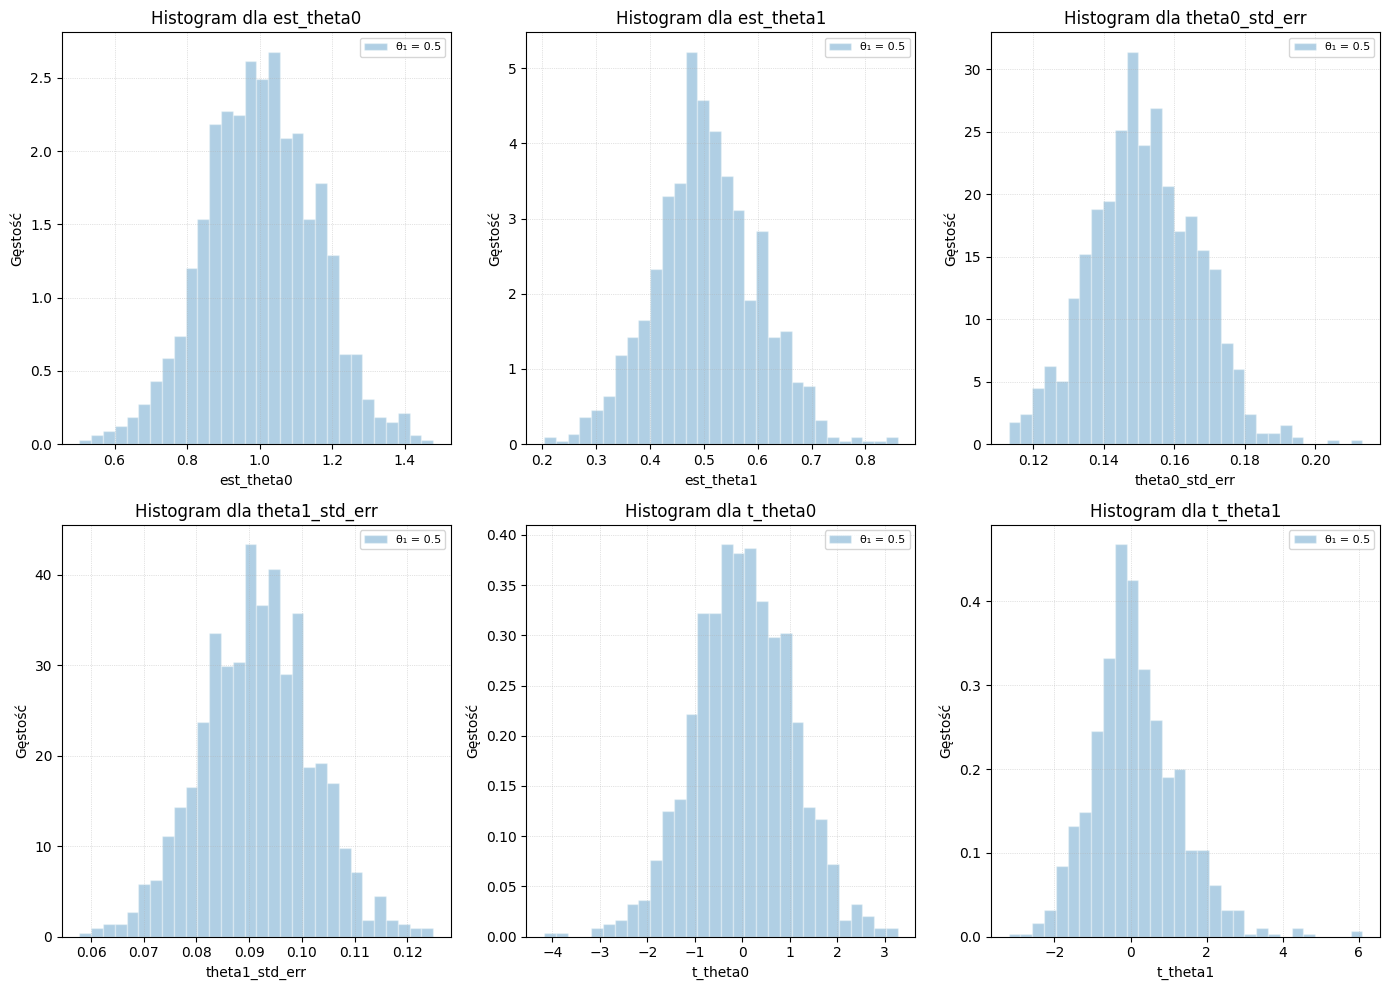

In [10]:
theta_keys = sorted(summaries.keys())
fig_rows, fig_cols = 2, 3
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(14, 10))
axes = axes.flatten()
color_map = plt.cm.get_cmap("tab10", max(len(theta_keys), 1))

for ax, col in zip(axes, columns):
    max_density = 0
    for idx, theta_key in enumerate(theta_keys):
        df = summaries[theta_key]
        data = df[col].dropna().to_numpy()

        if data.size == 0:
            continue

        ax.hist(
            data,
            bins=30,
            color=color_map(idx),
            alpha=0.35,
            edgecolor="white",
            density=True,
            label=f"θ₁ = {theta_key:g}"
        )


        # kde = stats.gaussian_kde(data)
        # x_grid = np.linspace(data.min(), data.max(), 400)
        # density_vals = kde(x_grid)
        # ax.plot(x_grid, density_vals, color=color_map(idx), linewidth=1.5, label=f"θ₁ = {theta_key:g}")
        # max_density = max(max_density, density_vals.max())

    # if max_density == 0:
    #     ax.text(0.5, 0.5, "Brak danych", transform=ax.transAxes, ha="center", va="center")
    #     ax.axis("off")
    #     continue

    ax.set_title(f"Histogram dla {col}")
    # ax.set_title(f"Histogram + KDE dla {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Gęstość")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")


plt.tight_layout()
plt.show()
